In [1]:
import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
with zipfile.ZipFile("credit+approval.zip", "r") as zip_ref:
    zip_ref.extractall("credit_approval")

In [3]:
column_names = [
    "A1", "A2", "A3", "A4", "A5",
    "A6", "A7", "A8", "A9", "A10",
    "A11", "A12", "A13", "A14", "A15",
    "A16"
]

df = pd.read_csv(
    "credit_approval/crx.data",
    header=None,
    names=column_names,
    na_values="?"
)

df.head()

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,A15,A16
0,b,30.83,0.000,u,g,w,v,1.25,t,t,1,f,g,202.0,0,+
1,a,58.67,4.460,u,g,q,h,3.04,t,t,6,f,g,43.0,560,+
2,a,24.50,0.500,u,g,q,h,1.50,t,f,0,f,g,280.0,824,+
3,b,27.83,1.540,u,g,w,v,3.75,t,t,5,t,g,100.0,3,+
4,b,20.17,5.625,u,g,w,v,1.71,t,f,0,f,s,120.0,0,+


In [4]:
print("Dataset shape:", df.shape)
df.info()

Dataset shape: (690, 16)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690 entries, 0 to 689
Data columns (total 16 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   A1      678 non-null    object 
 1   A2      678 non-null    float64
 2   A3      690 non-null    float64
 3   A4      684 non-null    object 
 4   A5      684 non-null    object 
 5   A6      681 non-null    object 
 6   A7      681 non-null    object 
 7   A8      690 non-null    float64
 8   A9      690 non-null    object 
 9   A10     690 non-null    object 
 10  A11     690 non-null    int64  
 11  A12     690 non-null    object 
 12  A13     690 non-null    object 
 13  A14     677 non-null    float64
 14  A15     690 non-null    int64  
 15  A16     690 non-null    object 
dtypes: float64(4), int64(2), object(10)
memory usage: 86.4+ KB


In [5]:
df.to_csv("credit_approval_dataset.csv", index=False)

In [6]:
#Task 2
# Count missing values in each column
missing_values = df.isnull().sum()

print("Missing values per column:")
print(missing_values)

Missing values per column:
A1     12
A2     12
A3      0
A4      6
A5      6
A6      9
A7      9
A8      0
A9      0
A10     0
A11     0
A12     0
A13     0
A14    13
A15     0
A16     0
dtype: int64


In [7]:
# Calculate the percentage of missing values in each column
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_summary = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage (%)": missing_percentage.round(2)
})

missing_summary

,Missing Values,Percentage (%)
A1,12,1.74
A2,12,1.74
A3,0,0.00
A4,6,0.87
A5,6,0.87
A6,9,1.30
A7,9,1.30
A8,0,0.00
A9,0,0.00
A10,0,0.00


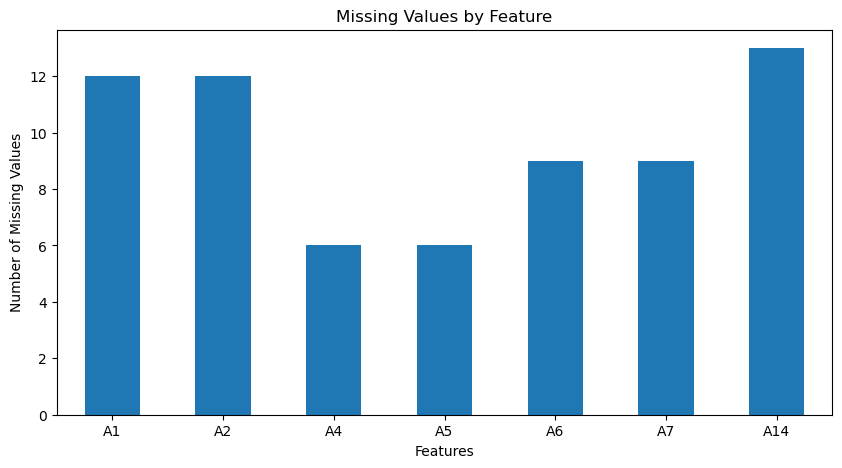

In [8]:
# Select only columns that contain missing values
missing_plot = missing_values[missing_values > 0]

plt.figure(figsize=(10, 5))

missing_plot.plot(kind="bar")

plt.title("Missing Values by Feature")
plt.xlabel("Features")
plt.ylabel("Number of Missing Values")
plt.xticks(rotation=0)

plt.show()

In [9]:
# Display descriptive statistics for numerical features
df.describe().T

,count,mean,std,min,25%,50%,75%,max
A2,678.0,31.568171,11.957862,13.75,22.6025,28.46,38.2300,80.25
A3,690.0,4.758725,4.978163,0.00,1.0000,2.75,7.2075,28.00
A8,690.0,2.223406,3.346513,0.00,0.1650,1.00,2.6250,28.50
A11,690.0,2.400000,4.862940,0.00,0.0000,0.00,3.0000,67.00
A14,677.0,184.014771,173.806768,0.00,75.0000,160.00,276.0000,2000.00
A15,690.0,1017.385507,5210.102598,0.00,0.0000,5.00,395.5000,100000.00


In [10]:
# Identify numerical features
numerical_features = df.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

# Identify categorical features
categorical_features = df.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['A2', 'A3', 'A8', 'A11', 'A14', 'A15']

Categorical features:
['A1', 'A4', 'A5', 'A6', 'A7', 'A9', 'A10', 'A12', 'A13', 'A16']


In [11]:
# Count the values in the target variable
class_counts = df["A16"].value_counts()

print("Class distribution:")
print(class_counts)

Class distribution:
A16
-    383
+    307
Name: count, dtype: int64


In [12]:
# Calculate percentage distribution of the target classes
class_percentage = (
    df["A16"].value_counts(normalize=True) * 100
).round(2)

print("Class distribution percentage:")
print(class_percentage)

Class distribution percentage:
A16
-    55.51
+    44.49
Name: proportion, dtype: float64


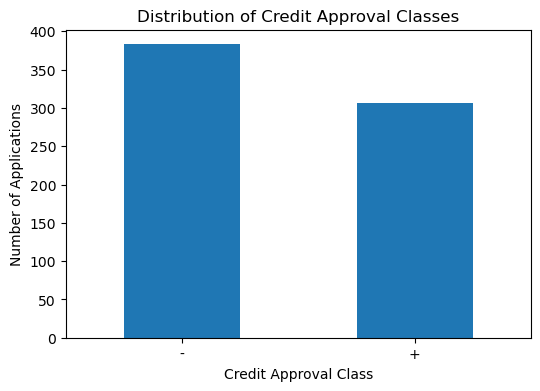

In [13]:
plt.figure(figsize=(6, 4))

df["A16"].value_counts().plot(kind="bar")

plt.title("Distribution of Credit Approval Classes")
plt.xlabel("Credit Approval Class")
plt.ylabel("Number of Applications")
plt.xticks(rotation=0)

plt.show()

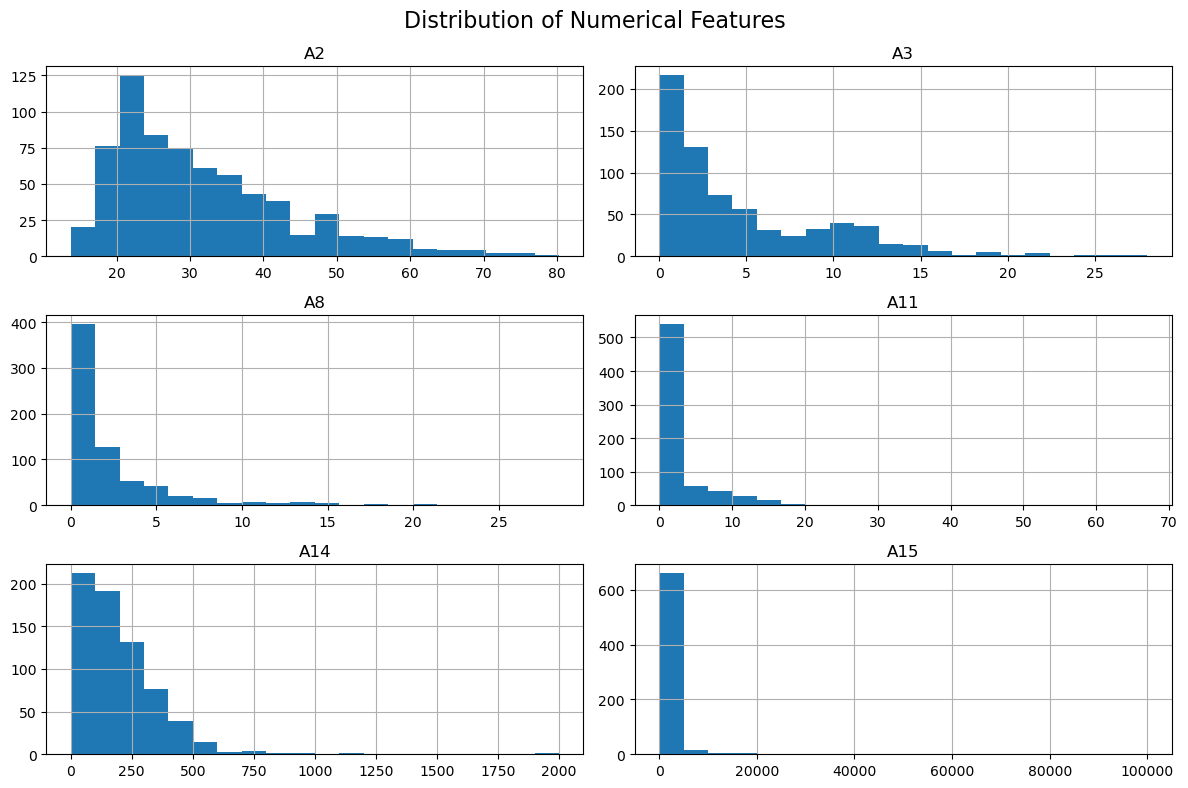

In [14]:
# Plot histograms for all numerical features
df[numerical_features].hist(
    figsize=(12, 8),
    bins=20
)

plt.suptitle("Distribution of Numerical Features", fontsize=16)

plt.tight_layout()

plt.show()

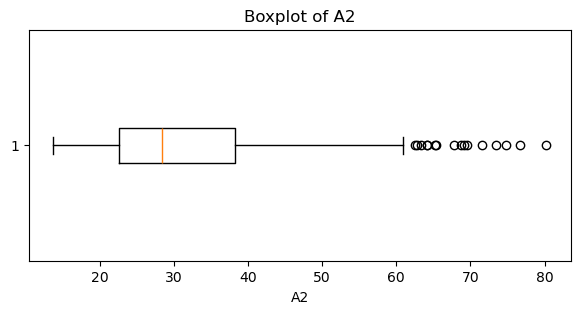

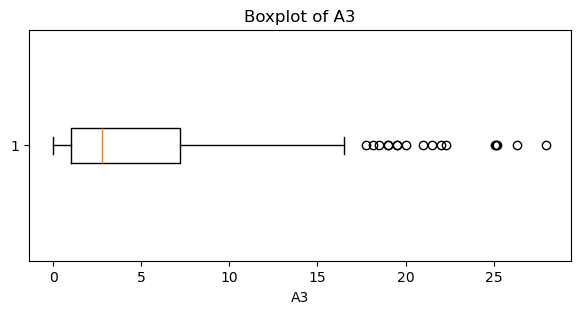

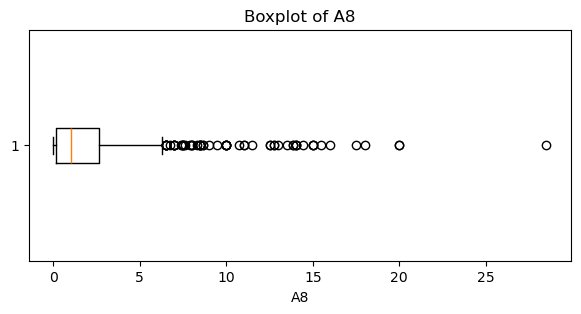

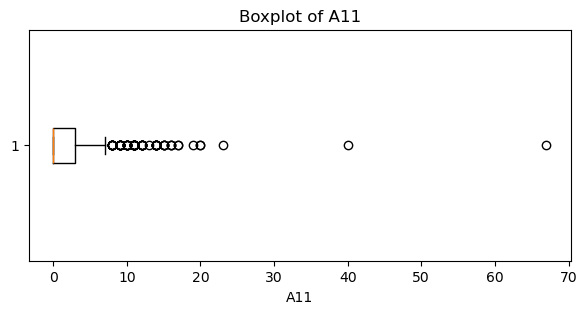

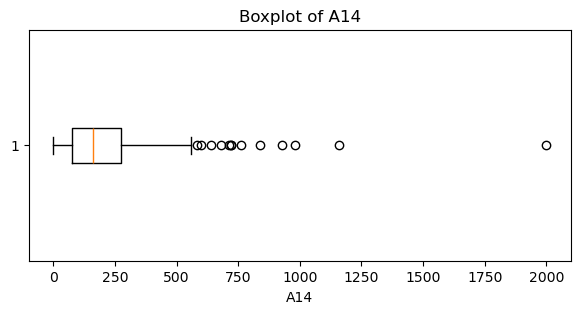

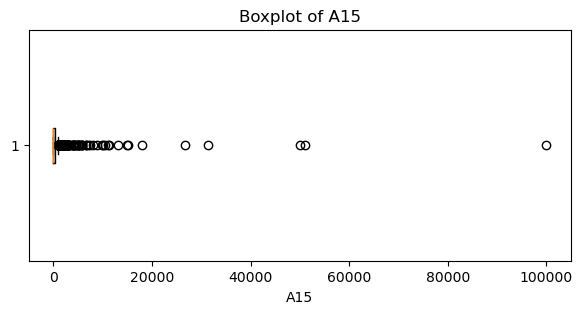

In [15]:
# Create boxplots for each numerical feature

for column in numerical_features:

    plt.figure(figsize=(7, 3))

    plt.boxplot(
        df[column].dropna(),
        vert=False
    )

    plt.title(f"Boxplot of {column}")
    plt.xlabel(column)

    plt.show()

In [16]:
# Detect potential outliers using the IQR method

outlier_counts = {}

for column in numerical_features:

    # Remove missing values before calculating quartiles
    data = df[column].dropna()

    # Calculate the first and third quartiles
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)

    # Calculate the interquartile range
    IQR = Q3 - Q1

    # Define lower and upper limits
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Find observations outside the limits
    outliers = data[
        (data < lower_bound) |
        (data > upper_bound)
    ]

    # Store the number of potential outliers
    outlier_counts[column] = len(outliers)

# Create a summary table
outlier_summary = pd.DataFrame.from_dict(
    outlier_counts,
    orient="index",
    columns=["Number of Potential Outliers"]
)

outlier_summary

,Number of Potential Outliers
A2,16
A3,17
A8,63
A11,79
A14,13
A15,113


In [17]:
#Task 3
# Separate predictor variables from the target variable
X = df.drop(columns=["A16"]).copy()
y = df["A16"].copy()

print("Predictor data shape:", X.shape)
print("Target data shape:", y.shape)

Predictor data shape: (690, 15)
Target data shape: (690,)


In [18]:
from sklearn.model_selection import train_test_split

In [19]:
# Split the dataset into 80% training and 20% testing data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)

print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (552, 15)
Testing features: (138, 15)
Training target: (552,)
Testing target: (138,)


In [20]:
# Make copies before modifying the training and test data
X_train = X_train.copy()
X_test = X_test.copy()

# Dictionary for storing the outlier boundaries
outlier_bounds = {}

# Calculate IQR limits using the training data only
for column in numerical_features:

    Q1 = X_train[column].quantile(0.25)
    Q3 = X_train[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Save the boundaries
    outlier_bounds[column] = (lower_bound, upper_bound)

    # Clip the training data
    X_train[column] = X_train[column].clip(
        lower=lower_bound,
        upper=upper_bound
    )

    # Apply the SAME boundaries to the test data
    X_test[column] = X_test[column].clip(
        lower=lower_bound,
        upper=upper_bound
    )

print("Outlier treatment completed.")

Outlier treatment completed.


In [21]:
# Display the IQR clipping boundaries
outlier_bounds_df = pd.DataFrame(
    outlier_bounds,
    index=["Lower Bound", "Upper Bound"]
).T

outlier_bounds_df

,Lower Bound,Upper Bound
A2,-0.7000,61.6200
A3,-8.7500,17.2500
A8,-3.3375,6.0025
A11,-4.5000,7.5000
A14,-215.0000,545.0000
A15,-600.0000,1000.0000


In [22]:
# Categorical predictor features only
categorical_input_features = [
    column for column in categorical_features
    if column != "A16"
]

print("Numerical predictor features:")
print(numerical_features)

print("\nCategorical predictor features:")
print(categorical_input_features)

Numerical predictor features:
['A2', 'A3', 'A8', 'A11', 'A14', 'A15']

Categorical predictor features:
['A1', 'A4', 'A5', 'A6', 'A7', 'A9', 'A10', 'A12', 'A13']


In [23]:
# Check missing values in the training data before imputation
print("Missing values in training data before imputation:")
print(X_train.isnull().sum())

Missing values in training data before imputation:
A1      7
A2      9
A3      0
A4      4
A5      4
A6      7
A7      7
A8      0
A9      0
A10     0
A11     0
A12     0
A13     0
A14    11
A15     0
dtype: int64


In [24]:
# Calculate medians from training data only
numeric_medians = X_train[numerical_features].median()

# Fill numerical missing values
X_train[numerical_features] = (
    X_train[numerical_features]
    .fillna(numeric_medians)
)

X_test[numerical_features] = (
    X_test[numerical_features]
    .fillna(numeric_medians)
)

print("Numerical missing values handled.")

Numerical missing values handled.


In [25]:
# Calculate the most frequent value for each categorical feature
categorical_modes = (
    X_train[categorical_input_features]
    .mode()
    .iloc[0]
)

# Fill categorical missing values
X_train[categorical_input_features] = (
    X_train[categorical_input_features]
    .fillna(categorical_modes)
)

X_test[categorical_input_features] = (
    X_test[categorical_input_features]
    .fillna(categorical_modes)
)

print("Categorical missing values handled.")

Categorical missing values handled.


In [26]:
print("Missing values in training data after imputation:")
print(X_train.isnull().sum())

print("\nTotal missing values in training data:")
print(X_train.isnull().sum().sum())

print("\nTotal missing values in test data:")
print(X_test.isnull().sum().sum())

Missing values in training data after imputation:
A1     0
A2     0
A3     0
A4     0
A5     0
A6     0
A7     0
A8     0
A9     0
A10    0
A11    0
A12    0
A13    0
A14    0
A15    0
dtype: int64

Total missing values in training data:
0

Total missing values in test data:
0


In [27]:
# Encode the target variable
y_train_encoded = y_train.map({
    "-": 0,
    "+": 1
})

y_test_encoded = y_test.map({
    "-": 0,
    "+": 1
})

print("Training target distribution:")
print(y_train_encoded.value_counts())

print("\nTest target distribution:")
print(y_test_encoded.value_counts())

Training target distribution:
A16
0    306
1    246
Name: count, dtype: int64

Test target distribution:
A16
0    77
1    61
Name: count, dtype: int64


In [28]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

In [29]:
# Create preprocessing transformer

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            StandardScaler(),
            numerical_features
        ),
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_input_features
        )
    ]
)

In [30]:
# Fit preprocessing only on the training data
# and transform the training data
X_train_processed = preprocessor.fit_transform(X_train)

# Apply the already learned preprocessing to the test data
X_test_processed = preprocessor.transform(X_test)

print("Training data before preprocessing:", X_train.shape)
print("Training data after preprocessing:", X_train_processed.shape)

print("\nTest data before preprocessing:", X_test.shape)
print("Test data after preprocessing:", X_test_processed.shape)

Training data before preprocessing: (552, 15)
Training data after preprocessing: (552, 46)

Test data before preprocessing: (138, 15)
Test data after preprocessing: (138, 46)


In [31]:
preprocessor.fit_transform(X_train)

array([[ 0.18748787, -0.93972334, -0.85521534, ...,  1.        ,
         0.        ,  0.        ],
       [ 0.94362663,  0.08137414,  2.16654491, ...,  1.        ,
         0.        ,  0.        ],
       [-1.06687504,  1.04930075, -0.38797231, ...,  1.        ,
         0.        ,  0.        ],
       ...,
       [-0.20070444, -0.25284268,  0.88864799, ...,  1.        ,
         0.        ,  0.        ],
       [-0.61178337, -0.48831362, -0.89862043, ...,  1.        ,
         0.        ,  0.        ],
       [-1.26493234, -0.95817037, -0.72755331, ...,  1.        ,
         0.        ,  0.        ]], shape=(552, 46))

In [32]:
preprocessor.transform(X_test)

array([[-0.17165604, -0.57837854,  0.12267581, ...,  1.        ,
         0.        ,  0.        ],
       [-1.27901641, -0.93972334, -0.75053248, ...,  0.        ,
         0.        ,  1.        ],
       [ 0.51758337,  0.39822904,  1.27163408, ...,  1.        ,
         0.        ,  0.        ],
       ...,
       [ 0.01143693, -0.84965842,  0.88864799, ...,  1.        ,
         0.        ,  0.        ],
       [ 0.45948656, -0.30709865,  2.16654491, ...,  1.        ,
         0.        ,  0.        ],
       [ 1.54484057, -0.68689049, -0.89862043, ...,  1.        ,
         0.        ,  0.        ]], shape=(138, 46))

In [33]:
# Get the names of the transformed features
processed_feature_names = preprocessor.get_feature_names_out()

print("Number of features after preprocessing:",
      len(processed_feature_names))

print("\nProcessed feature names:")
print(processed_feature_names)

Number of features after preprocessing: 46

Processed feature names:
['numerical__A2' 'numerical__A3' 'numerical__A8' 'numerical__A11'
 'numerical__A14' 'numerical__A15' 'categorical__A1_a' 'categorical__A1_b'
 'categorical__A4_l' 'categorical__A4_u' 'categorical__A4_y'
 'categorical__A5_g' 'categorical__A5_gg' 'categorical__A5_p'
 'categorical__A6_aa' 'categorical__A6_c' 'categorical__A6_cc'
 'categorical__A6_d' 'categorical__A6_e' 'categorical__A6_ff'
 'categorical__A6_i' 'categorical__A6_j' 'categorical__A6_k'
 'categorical__A6_m' 'categorical__A6_q' 'categorical__A6_r'
 'categorical__A6_w' 'categorical__A6_x' 'categorical__A7_bb'
 'categorical__A7_dd' 'categorical__A7_ff' 'categorical__A7_h'
 'categorical__A7_j' 'categorical__A7_n' 'categorical__A7_o'
 'categorical__A7_v' 'categorical__A7_z' 'categorical__A9_f'
 'categorical__A9_t' 'categorical__A10_f' 'categorical__A10_t'
 'categorical__A12_f' 'categorical__A12_t' 'categorical__A13_g'
 'categorical__A13_p' 'categorical__A13_s']


In [34]:
# Extract the scaled numerical part for inspection
scaled_numerical = (
    preprocessor
    .named_transformers_["numerical"]
    .transform(X_train[numerical_features])
)

scaled_numerical_df = pd.DataFrame(
    scaled_numerical,
    columns=numerical_features
)

scaled_numerical_df.head()

,A2,A3,A8,A11,A14,A15
0,0.187488,-0.939723,-0.855215,-0.670315,0.056136,-0.667120
1,0.943627,0.081374,2.166545,-0.670315,-0.569721,-0.667120
2,-1.066875,1.049301,-0.387972,-0.670315,-0.797305,0.381414
3,2.655722,0.181205,2.166545,-0.299374,-1.224026,-0.667120
4,0.246465,-0.632635,-0.770958,-0.670315,-0.064768,-0.667120


In [35]:
scaled_numerical_df.mean().round(4)

A2    -0.0
A3    -0.0
A8    -0.0
A11   -0.0
A14    0.0
A15    0.0
dtype: float64

In [36]:
from sklearn.linear_model import LogisticRegression

In [37]:
# Create the Logistic Regression classifier
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

In [38]:
# Train the model using the preprocessed training data
logistic_model.fit(
    X_train_processed,
    y_train_encoded
)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [39]:
# Predict the classes of the test data
y_pred = logistic_model.predict(X_test_processed)

print("First 10 predictions:")
print(y_pred[:10])

print("\nFirst 10 actual values:")
print(y_test_encoded.iloc[:10].values)

First 10 predictions:
[0 0 1 1 0 0 0 1 1 1]

First 10 actual values:
[0 0 1 0 0 0 0 0 0 0]


In [40]:
from sklearn.metrics import accuracy_score, f1_score

In [41]:
# Calculate model performance metrics
accuracy = accuracy_score(
    y_test_encoded,
    y_pred
)

f1 = f1_score(
    y_test_encoded,
    y_pred
)

print("Accuracy:", round(accuracy, 4))
print("F1-score:", round(f1, 4))

Accuracy: 0.8333
F1-score: 0.8189


In [42]:
print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"F1-score: {f1 * 100:.2f}%")

Accuracy: 83.33%
F1-score: 81.89%


In [43]:
from sklearn.metrics import confusion_matrix

# Generate confusion matrix
cm = confusion_matrix(
    y_test_encoded,
    y_pred
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[63 14]
 [ 9 52]]


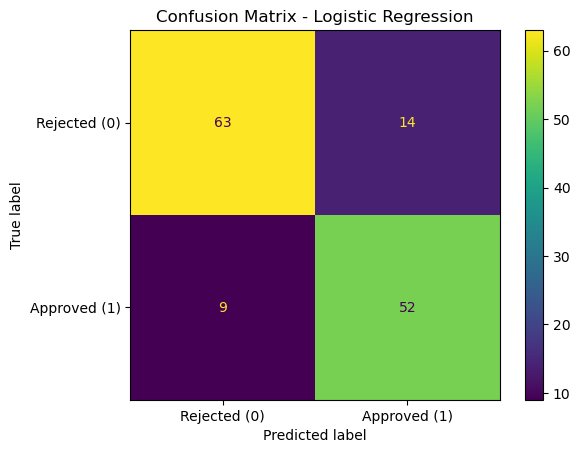

In [44]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Rejected (0)",
        "Approved (1)"
    ]
).plot()

plt.title("Confusion Matrix - Logistic Regression")
plt.show()